In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
raw_data = pd.read_csv("asr_fairness_audio/metadata.tsv", sep='\t')
raw_data.head()

,hash_name,transcription,age,gender,first_language,socioeconomic_bkgd,ethnicity
0,ca1920051b7fdc279c45b5211b261cf0,hey facebook answer the call,18 - 22,female,English,Low,White
1,61b469ebfd9e2ee5ec3295b23d282ec4,hey facebook remove video,31 - 45,female,English,Medium,White
2,eb7e37f0cf0c1b5e3587f2ee6a4bd3ba,i wanna look for hotels for next weekend's vac...,18 - 22,male,English,Low,White
3,d1354340600029ae49d0efac5d1dcb14,hey facebook stop current playing song,18 - 22,male,English,Medium,Black or African American
4,46b92c6d41ef7b63d1f0ccb40bb1d3c5,hey facebook call the last dialed number,31 - 45,male,English,Low,Black or African American


In [3]:
raw_data.groupby(by="gender",as_index=False).count()

,gender,hash_name,transcription,age,first_language,socioeconomic_bkgd,ethnicity
0,female,14422,14421,14422,14422,14422,14422
1,male,12049,12049,12049,12049,12049,12049


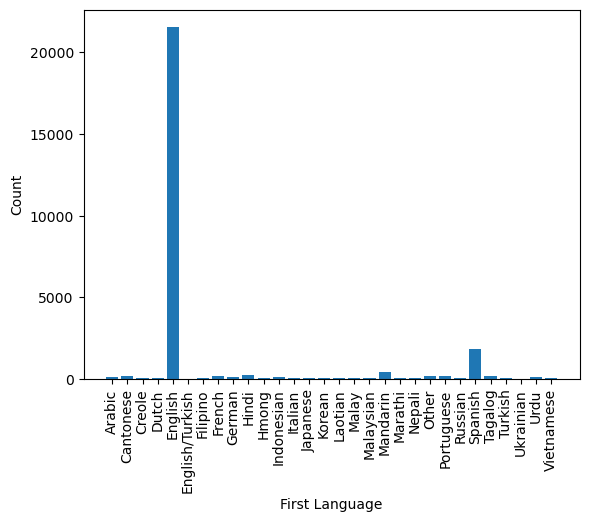

In [4]:
g = raw_data.groupby(by="first_language",as_index=False).count()

fig, ax = plt.subplots(1,1)
ax.bar(np.arange(len(g)), g.hash_name)
ax.set_xticks(np.arange(len(g)), g.first_language, rotation=90)
ax.set_ylabel("Count")
ax.set_xlabel("First Language")
plt.show()

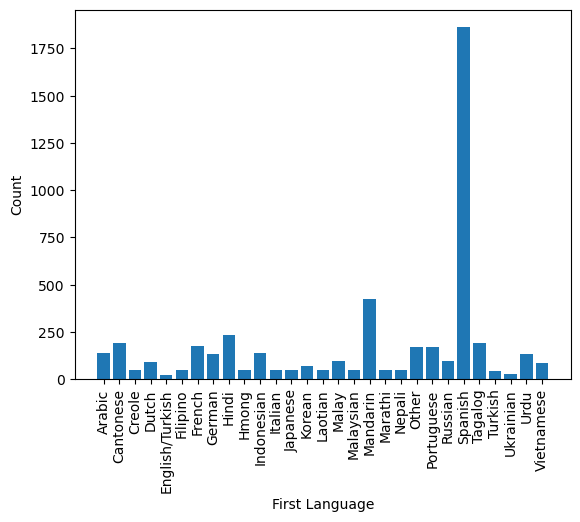

In [5]:
g = raw_data.groupby(by="first_language",as_index=False).count()
g.drop(index=4,inplace=True)

fig, ax = plt.subplots(1,1)
ax.bar(np.arange(len(g)), g.hash_name)
ax.set_xticks(np.arange(len(g)), g.first_language, rotation=90)
ax.set_ylabel("Count")
ax.set_xlabel("First Language")
plt.show()

In [9]:
print("Total # of samples Hindi: ", len(raw_data[raw_data["first_language"]=="Hindi"]))
print("Total # of samples Urdu: ", len(raw_data[raw_data["first_language"]=="Urdu"]))

Total # of samples Hindi:  233
Total # of samples Urdu:  136


In [14]:
import shutil
import os

n_samples = 100

langs = ["English","Hindi","Urdu"]

filename_dict = {l:[] for l in langs}

for l in langs:
    lang_subset = raw_data[raw_data["first_language"]==l]

    # random sample of files
    rand_samp = lang_subset.sample(n_samples)
    files = rand_samp["hash_name"].tolist()
    filename_dict[l] = files

    # save file name and transcription
    rand_samp.to_csv(f"audio_subset/{l}/{l}_metadata.csv")

    # copy files over
    for file in files:
        shutil.copy(f"asr_fairness_audio/{file}.wav", f"audio_subset/{l}/")